# Diabetes Prediction Using Machine Learning
Author: Mahdis Ebrahimi

## 1. Dataset Loading

In [1]:
import pandas as pd
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Dataset Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Data Cleaning

In [4]:
cols = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [5]:
cols = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols:
    median = df[col].median()
    df[col] = df[col].replace(0, median)
print("Missing values replaced successfully")

Missing values replaced successfully


In [6]:
for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


## 4. Exploratory Data Analysis

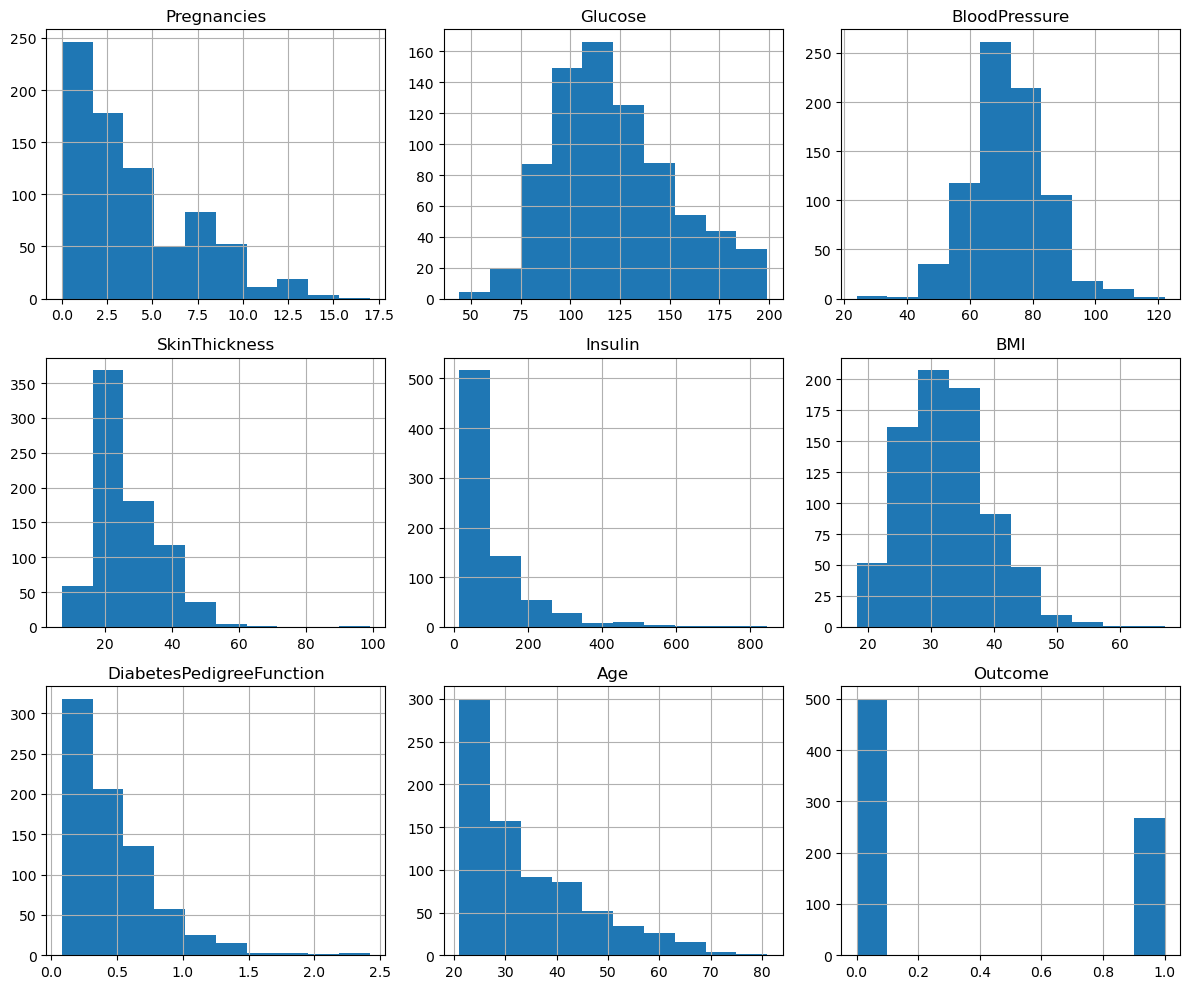

In [7]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()


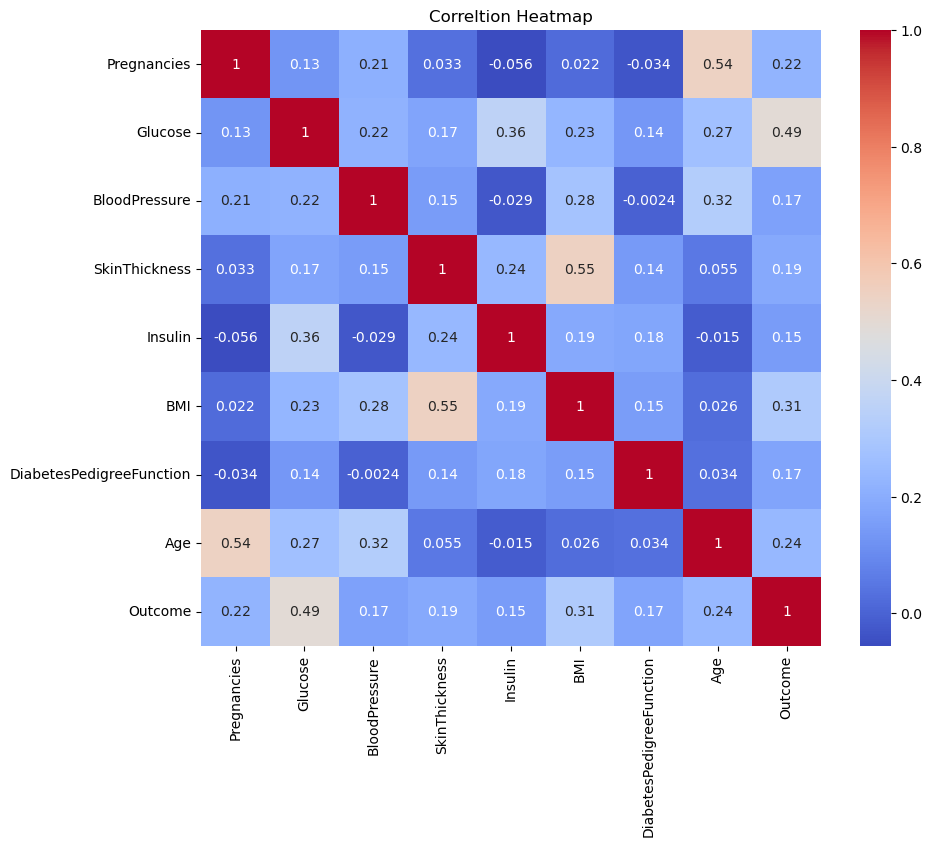

In [8]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correltion Heatmap")
plt.show()

## 5. Ttain-Test Split

In [9]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


## 6. Baseline Model: Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154

[[80 20]
 [26 28]]


## 7. Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [14]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.7077922077922078
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## 8. Random Forest Classifier

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



## 9. Class Imbalance Analysis

In [16]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## 10. Handing Imbalanced Data With SMOTE

In [17]:
from imblearn.over_sampling import SMOTE
print("SMOTE is available")

SMOTE is available


In [18]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

After SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


## 11. Random Forest with SMOTE

In [19]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_pred = rf_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_smote_pred))
print(classification_report(y_test, rf_smote_pred))


Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.87      0.73      0.79       100
           1       0.61      0.80      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



## 12. Confusion Matrix Visualization

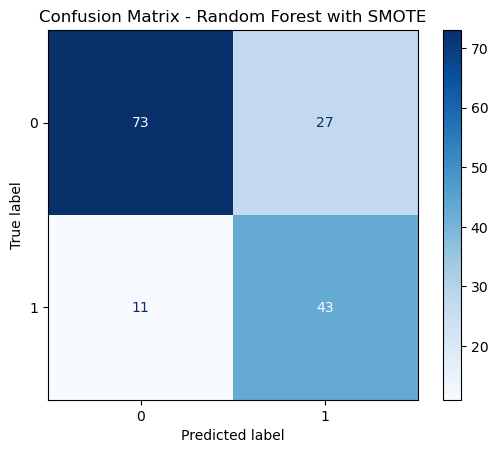

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_smote_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest with SMOTE")
plt.show()


## 13. ROC Curve and AUC Score

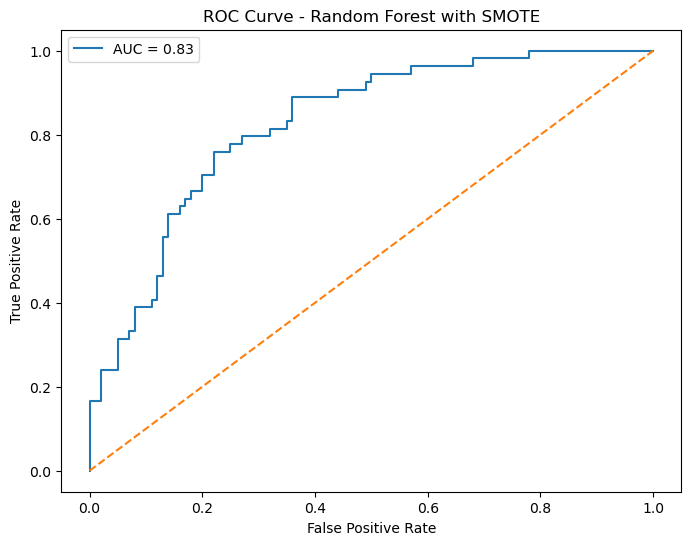

AUC Score: 0.8253703703703703


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = rf_smote.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest with SMOTE")
plt.legend()

plt.show()

print("AUC Score:", auc_score)

## 14. Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_smote,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:", cv_scores)
print("Mean F1 score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


F1 scores for each fold: [0.75294118 0.7875     0.78823529 0.82278481 0.80239521]
Mean F1 score: 0.7907712980591312
Standard deviation: 0.02283957565430741


## 15. Hyperparameter Tuning

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)


Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Best F1 Score: 0.830386857459174


## 16. Final Optimized Model

In [24]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train_smote, y_train_smote)

best_pred = best_rf.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred))


Final Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154



## 17. Final Model Visualization

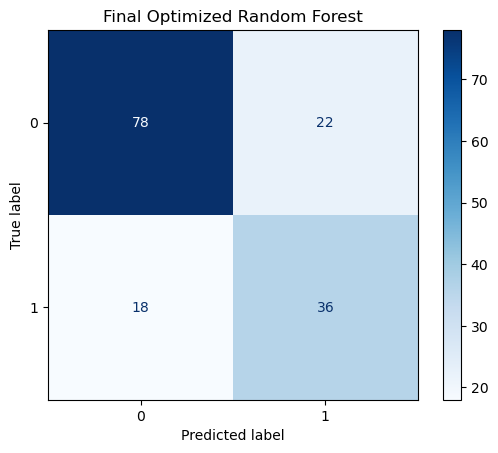

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap='Blues')
plt.title("Final Optimized Random Forest")
plt.show()


## 18. Final ROC Curve and AUC Score

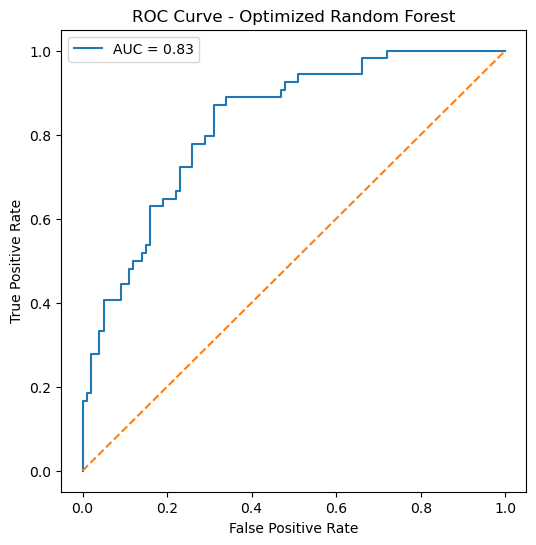

AUC Score: 0.827962962962963


In [26]:
from sklearn.metrics import roc_curve, auc

y_prob_best = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Random Forest")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

## 19. Conclusion
In this project, a diabetes prediction model was developed using machine learning. After cleaning the dataset and replacing invalid zero values, different models were tested. Logistic Regression was used as a baseline model, then Random Forest was applied. Because the dataset was imbalanced, SMOTE was used to balance the training data. Finally, hyperparameter tuning improved the Random Forest model. The final model achieved acceptable performance, with an AUC score of about 0.83.